In [5]:
import sys
import os
import matplotlib.pyplot as plt
import networkx as nx
import json

# Add the parent directory to the path to import from src
sys.path.append(os.path.abspath(".."))
from concept_creator.critical_point_concept_service import (
    CriticalPointConceptService,
)

# Configuration
uri = "bolt://localhost:7687"
user = "neo4j"
password = "111122223333"
session_id = "3_1"
concept_name = session_id



In [6]:
# Create the concept with visualization
service = CriticalPointConceptService(uri, user, password)
concept_id, concept_graph = service.create_concept_incrementally(
    session_id, concept_name, steps=2
)

INFO:root:Initializing ConceptCreationRepository
INFO:root:Database connection established
INFO:concept_creator.critical_point_concept_service:CriticalPointConceptService initialized.
INFO:concept_creator.critical_point_concept_service:Creating concept for session 3_1 using Critical Point approach.
INFO:root:Getting image IDs for session 3_1
INFO:concept_creator.critical_point_concept_service:Initialized concept with graph from image f223bee3-2834-49d2-b96f-198fd7fc749f. Nodes: 19
INFO:concept_creator.critical_point_concept_service:Processing image 2/26: be672d98-921d-4e9d-90c7-3295bf51daae
INFO:graph_minor_finder:Finding maximum common minor between graphs: concept (19 nodes) and image (19 nodes)
INFO:critical_point_preprocessor:Preprocessing graphs for critical point compatibility
INFO:critical_point_preprocessor:Graph1 critical points: {'IntersectionPoint': 1, 'CornerPoint': 0, 'EndPoint': 2, 'StartPoint': 1}
INFO:critical_point_preprocessor:Graph2 critical points: {'IntersectionPoi

In [7]:
def visualize_concept(concept_graph: nx.Graph):
    # Extract node positions from the graph
    pos = {}
    for node_id, node_data in concept_graph.nodes(data=True):
        # For regular points
        if 'x' in node_data and 'y' in node_data:
            x = node_data['x']['center']
            y = node_data['y']['center']
                
            pos[node_id] = (x, y)
            
        if 'labels' in node_data and 'Vector' in node_data['labels']:
                x1 = node_data['x1']
                x2 = node_data['x2']
                y1 = node_data['y1']
                y2 = node_data['y2']
                
                x1 = x1['center'] if isinstance(x1, dict) and 'center' in x1 else x1
                x2 = x2['center'] if isinstance(x2, dict) and 'center' in x2 else x2
                y1 = y1['center'] if isinstance(y1, dict) and 'center' in y1 else y1
                y2 = y2['center'] if isinstance(y2, dict) and 'center' in y2 else y2
                
                pos[node_id] = (x1, y1)
    
    # Create figure
    plt.figure(figsize=(12, 10))
    
    node_to_color = {
        "IntersectionPoint": "red",
        "CornerPoint": "green",
        "EndPoint": "blue",
        "QuadrantChangePoint": "purple",
        "StartPoint": "orange"
    }
    # Draw nodes with colors based on their labels
    node_colors = []
    labels_for_nodes = {}
    for node_id in concept_graph.nodes():
        node_data = concept_graph.nodes[node_id]
        
        # Try to get labels from the node data
        labels = []
        if 'labels' in node_data:
            labels = node_data['labels']
            
        labels_for_nodes[node_id] = ', '.join(str(label) for label in labels) + ' ' + str(node_id.split(':')[-1]) if labels else str(node_id)

        
        # If still empty, check if any attribute has 'label' in its name
        if not labels:
            for key in node_data:
                if 'label' in key.lower() and node_data[key]:
                    if isinstance(node_data[key], list):
                        labels = node_data[key]
                    else:
                        labels = [str(node_data[key])]
                    break
        
        # Check if any label matches our color mapping
        color = 'lightblue'  # Default color
        for label in labels:
            label_str = str(label)  # Convert to string if it's not already
            if label_str in node_to_color:
                color = node_to_color[label_str]
                break
        
        node_colors.append(color)
    
    # Draw the graph
    nx.draw_networkx_nodes(concept_graph, pos, node_color=node_colors, node_size=500)
    nx.draw_networkx_edges(concept_graph, pos, width=2, alpha=0.7, edge_color='gray')
    nx.draw_networkx_labels(concept_graph, pos, font_size=12, font_weight='bold', labels=labels_for_nodes)
    
    # Add a legend
    legend_elements = [
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=10, label='StartPoint'),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=10, label='CornerPoint'),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=10, label='Vector'),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=10, label='Other'),
        plt.Line2D([0], [0], color='blue', lw=2, label='Vector Direction')
    ]
    plt.legend(handles=legend_elements, loc='upper right')
    
    plt.title('Concept Graph Visualization')
    plt.axis('equal')  # Equal aspect ratio
    plt.grid(True)
    plt.gca().invert_yaxis()  # Invert y-axis to match image coordinates
    plt.tight_layout()
    
    # return plt.gcf()  # Return the figure for further customization if needed

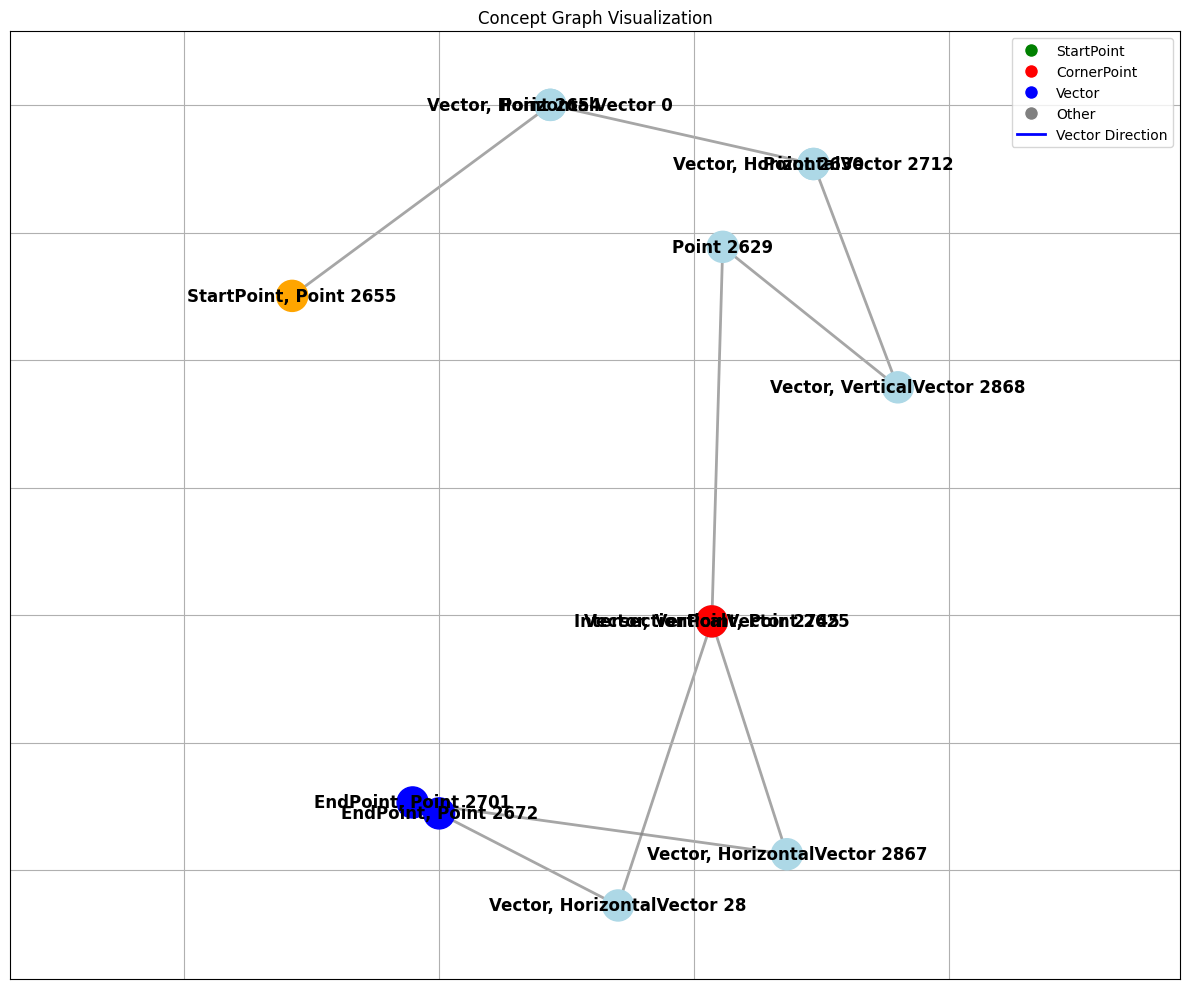

In [8]:
visualize_concept(concept_graph)

In [9]:
# Printing the graph properties per node
for node in concept_graph.nodes():
    print(f"Node {node}: {concept_graph.nodes[node]}")

# Create a directory for saved graphs if it doesn't exist
save_dir = "saved_graphs"
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

# Convert the graph to a JSON-serializable format
graph_data = nx.node_link_data(concept_graph)

# Save the graph with a descriptive filename
json_filename = os.path.join(save_dir, "concept_graph.json")
with open(json_filename, "w") as f:
    json.dump(graph_data, f, indent=2)

print(f"Graph saved to {json_filename} in JSON format")



Node 4:9e1c8335-dc1b-46bc-b817-da0e4e40f10b:2655: {'labels': ['StartPoint', 'Point'], 'y': {'min': 71.6513295389561, 'max': 98.28289921623686, 'type': 'range', 'center': 84.96711437759649}, 'intersection_points_count': 1, 'corner_points_count': 1, 'relative_distance': 0.3, 'normalized_x': {'min': -0.4, 'max': -0.2, 'type': 'range', 'center': -0.30000000000000004}, 'contour_type': 'OPEN', 'vectors_count': 9, 'session_id': '3_1', 'monotony': 'NON_MONOTONIC', 'quadrant_change_count': 5, 'cycle_count': 0, 'normalized_y': {'min': -0.3, 'max': -0.0, 'type': 'range', 'center': -0.15}, 'x': {'min': 61.43681745596051, 'max': 75.49810254893853, 'type': 'range', 'center': 68.46746000244953}, 'endpoints_count': 2}
Node 4:9e1c8335-dc1b-46bc-b817-da0e4e40f10b:0: {'labels': ['Vector', 'HorizontalVector'], 'x1': {'min': 82.4871576808206, 'max': 94.93110253252257, 'type': 'range', 'center': 88.7091301066716}, 'quadrant_change_count': 5, 'direction_sequence_index': 0, 'x2': {'min': 61.43681745596051, 'm

/Users/mlapin/anaconda3/envs/natural_agi/lib/python3.11/site-packages/networkx/readwrite/json_graph/node_link.py:142: FutureWarning: 
The default value will be `edges="edges" in NetworkX 3.6.

To make this warning go away, explicitly set the edges kwarg, e.g.:

  nx.node_link_data(G, edges="links") to preserve current behavior, or
  nx.node_link_data(G, edges="edges") for forward compatibility.
  warnings.warn(
